# Headline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Download

In [3]:
!pip install vnstock
!pip install pmdarima
!pip install arch
!pip install nolds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.4/277.4 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 14.7 MB/s eta 0:00:00


## Import

In [2]:
from vnstock import *
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

import statsmodels.api as sm

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import grangercausalitytests

import nolds
from statsmodels.tsa.stattools import bds

Version Vnstock 4.0.4 is available. Please update using: `pip install vnstock --upgrade`.
Release history: https://vnstocks.com/docs/release-history
Current version: 3.3.0

Version Vnai 2.4.8 is available. Please update using: `pip install vnai --upgrade`.
Release history: https://pypi.org/project/vnai/#history
Current version: 2.2.3

ModuleNotFoundError: No module named 'nolds'

# Data Input

In [1]:
data = pd.read_csv('Data Sources/DIG_data_set.csv')
#data.drop(['target'], axis=1, inplace=True)

data

NameError: name 'pd' is not defined

# Causality Test:

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

def get_best_granger_features(data, target_col, features, max_lag=10):
    """
    Tests Granger Causality for each feature against the target.
    Returns:
        1. best_lags: Dict {feature_name: optimal_lag}
        2. results_df: DataFrame with detailed stats
    """
    best_lags = {}
    detailed_results = []

    for feature in features:
        if feature == target_col:
            continue

        # --- CRITICAL FIX: Column Order ---
        # statsmodels tests if the SECOND column causes the FIRST column.
        # We want to know if 'feature' causes 'target_col'.
        # Therefore, order must be: [target_col, feature]
        test_df = data[[target_col, feature]].dropna()

        try:
            # verbose=False suppresses the massive text output
            test_output = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
        except Exception as e:
            print(f"Skipping {feature} due to error: {e}")
            continue

        # Track the best lag for this specific feature
        best_f_score = -1
        best_lag_for_feature = -1
        is_significant = False

        for lag, result in test_output.items():
            # result[0] contains tests (F-test, etc.)
            # result[0]['ssr_ftest'] = (F-statistic, p-value, df_denom, df_num)
            f_stat = result[0]['ssr_ftest'][0]
            p_val = result[0]['ssr_ftest'][1]

            # Save detail
            detailed_results.append({
                'Feature': feature,
                'Lag': lag,
                'F_Statistic': f_stat,
                'P_Value': p_val
            })

            # Check for significance and max predictive power
            if p_val < 0.05:
                is_significant = True
                if f_stat > best_f_score:
                    best_f_score = f_stat
                    best_lag_for_feature = lag

        # Only keep the feature if it had at least one significant lag
        if is_significant:
            best_lags[feature] = best_lag_for_feature

    return best_lags, pd.DataFrame(detailed_results)

# --- USAGE ---

# 1. Define your features (exclude target and non-numeric)
feature_cols = [c for c in data.columns if c not in ['log_ret', 'date', 'timestamp']]

# 2. Run the Optimizer
# Note: Pass the raw 'data', not the manually shifted 'df'
# (grangercausalitytests handles the shifting internally)
optimal_lags, stats_df = get_best_granger_features(data.copy(), target_col='log_ret', features=feature_cols)

print(f"Selected {len(optimal_lags)} predictive features.")
print(optimal_lags)

verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print 

Selected 30 predictive features.
{'volume_em': np.int64(1), 'volume_sma_em': np.int64(3), 'volume_mfi': np.int64(1), 'volatility_bbp': np.int64(1), 'volatility_bbhi': np.int64(4), 'volatility_bbli': np.int64(2), 'volatility_kcw': np.int64(2), 'volatility_kcp': np.int64(1), 'volatility_kcli': np.int64(8), 'volatility_ui': np.int64(2), 'trend_macd': np.int64(2), 'trend_macd_diff': np.int64(1), 'trend_vortex_ind_pos': np.int64(1), 'trend_vortex_ind_neg': np.int64(1), 'trend_trix': np.int64(8), 'trend_dpo': np.int64(2), 'trend_kst_diff': np.int64(5), 'trend_adx_pos': np.int64(1), 'trend_adx_neg': np.int64(1), 'momentum_rsi': np.int64(1), 'momentum_tsi': np.int64(1), 'momentum_stoch': np.int64(1), 'momentum_stoch_signal': np.int64(1), 'momentum_roc': np.int64(1), 'momentum_ppo_hist': np.int64(1), 'momentum_pvo': np.int64(2), 'momentum_pvo_hist': np.int64(2), 'others_dr': np.int64(8), 'roll_skew_20': np.int64(2), 'z_score': np.int64(1)}


verbose is deprecated since functions should not print results


# ARIMAX

## Prepare Data for ARIMAX Model

### causality lags:

In [ ]:
def build_model_dataset(data, target_col, lag_map):
    """
    Constructs X (features) and y (target) based on the optimal lags found.
    """
    X = pd.DataFrame(index=data.index)

    # 1. Create Lagged Features
    for feature, lag in lag_map.items():
        col_name = f"{feature}_lag{lag}"
        X[col_name] = data[feature].shift(lag)

    # 2. Add Target (Ensure it's aligned)
    # If we are predicting 'log_ret' at time t, we simply take log_ret at time t.
    # The features are already shifted to t-lag.
    y = data[target_col]

    # 3. Combine and Drop NaNs (created by shifting)
    final_df = pd.concat([X, y], axis=1).dropna()

    return final_df.drop(columns=[target_col]), final_df[target_col]

# Build X and y
X, y = build_model_dataset(data, 'log_ret', optimal_lags)

# Scaling for the target column is important
y = y * 100

print(f"Final Dataset Shape: {X.shape}")
display(X.head())

Final Dataset Shape: (2235, 30)


,volume_em_lag1,volume_sma_em_lag3,volume_mfi_lag1,volatility_bbp_lag1,volatility_bbhi_lag4,volatility_bbli_lag2,volatility_kcw_lag2,volatility_kcp_lag1,volatility_kcli_lag8,volatility_ui_lag2,...,momentum_tsi_lag1,momentum_stoch_lag1,momentum_stoch_signal_lag1,momentum_roc_lag1,momentum_ppo_hist_lag1,momentum_pvo_lag2,momentum_pvo_hist_lag2,others_dr_lag8,roll_skew_20_lag2,z_score_lag1
8,3.036028,0.145219,59.975766,1.099983,0.0,0.0,5.491404,1.236842,0.0,2.357961,...,28.968211,77.966102,79.647237,8.684211,0.106912,-8.014639,-1.442734,1.275510,0.367544,1.364451
9,0.000000,0.082004,59.992756,0.849974,0.0,0.0,6.761566,0.779851,0.0,2.357961,...,28.270734,62.711864,73.721924,7.446809,0.081838,-2.090583,3.585058,-1.259446,0.331131,0.906684
10,-0.793481,0.298863,61.312749,0.732559,0.0,0.0,6.759142,0.585979,0.0,2.413464,...,26.724227,55.932203,65.536723,6.382979,-0.028572,-7.250411,-1.259816,1.275510,0.382430,0.832189
11,0.786009,0.354076,66.811589,0.713452,1.0,0.0,6.334311,0.562667,0.0,2.421396,...,25.526032,55.932203,58.192090,6.382979,-0.121375,-10.499275,-3.606944,-3.274559,0.418029,1.105840
12,0.000000,0.330026,76.249014,0.783642,0.0,0.0,6.274575,0.677419,0.0,2.319676,...,25.170405,59.259259,57.041222,3.061224,-0.133612,-15.033989,-6.513326,1.041667,0.268596,0.672360


## ARIMAX Model Fitting

### Subtask:
Execute `pmdarima.auto_arima` again to determine the optimal (p, d, q) orders and fit the ARIMAX model using `y_arima` as the endogenous variable and `X_arima` as exogenous variables.

In [ ]:
import pmdarima as pm
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ---------------------------------------------------------
# ASSUMPTION: You have 'X' and 'y' from the previous Granger step
# X = The DataFrame of shifted, optimal lags
# y = The target series (log_ret)
# ---------------------------------------------------------

# 1. Train/Test Split (Standard 80/20 or time-based)
train_size = int(len(y) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training on {len(y_train)} samples with {X_train.shape[1]} features.")

# 2. Initial Auto-ARIMA Search
# We find the best (p,d,q) order using the Full Granger Feature Set first.
print("\n--- Step 1: Finding Best ARIMA Orders (Auto-ARIMA) ---")
base_model = pm.auto_arima(
    y_train,
    exogenous=X_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,           # Let model determine differencing
    seasonal=False,   # Set to True if you have explicit seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

best_order = base_model.order
print(f"Best Order Found: {best_order}")

# 3. Refinement: Backward Elimination on SARIMAX
# Auto-ARIMA finds the best order, but doesn't drop insignificant exogenous vars.
# We will now loop using statsmodels to drop features with P-value > 0.05.

print("\n--- Step 2: Backward Elimination of Insignificant Features ---")
current_X_train = X_train.copy()
current_X_test = X_test.copy()

while True:
    # Fit the SARIMAX model with the current feature set
    # Note: We enforce the order found by auto_arima to keep comparisons stable
    model_sm = sm.tsa.statespace.SARIMAX(
        y_train,
        exog=current_X_train,
        order=best_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    # Get p-values for just the exogenous variables (exclude ar/ma params)
    p_values = model_sm.pvalues

    # Filter to get only exogenous columns (those in our X matrix)
    # We ignore "ar.L1", "ma.L1", "sigma2" etc.
    exog_p_values = p_values[p_values.index.isin(current_X_train.columns)]

    if exog_p_values.empty:
        print("No exogenous features remaining!")
        break

    # Find the worst feature
    max_p_value = exog_p_values.max()
    worst_feature = exog_p_values.idxmax()

    # Threshold check
    if max_p_value > 0.05:
        print(f"Dropping '{worst_feature}' (p-value: {max_p_value:.4f})")
        current_X_train = current_X_train.drop(columns=[worst_feature])
        current_X_test = current_X_test.drop(columns=[worst_feature])
    else:
        print("All remaining features are significant (p < 0.05).")
        break

# 4. Final Model Summary
print("\n--- Final Refined Model Results ---")
print(model_sm.summary())

print(f"\nFinal Feature Count: {current_X_train.shape[1]}")

Training on 1788 samples with 30 features.

--- Step 1: Finding Best ARIMA Orders (Auto-ARIMA) ---
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=9123.433, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=9101.435, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=9102.680, Time=0.10 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=9102.337, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=9098.018, Time=0.36 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=9096.739, Time=1.43 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=9097.967, Time=1.78 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=9098.278, Time=5.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=9096.532, Time=1.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=9103.237, Time=0.44 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=9098.088, Time=1.27 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=9103.468, Time=0.95 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=9100.054, Time=4.57 sec


An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
Maximum Likelihood optimization failed to converge. Check mle_retvals


Dropping 'momentum_pvo_hist_lag2' (p-value: 0.9752)


An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
Maximum Likelihood optimization failed to converge. Check mle_retvals


Dropping 'volume_mfi_lag1' (p-value: 0.9047)


...

Maximum Likelihood optimization failed to converge. Check mle_retvals


Dropping 'volume_em_lag1' (p-value: 0.1194)


An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.


All remaining features are significant (p < 0.05).

--- Final Refined Model Results ---
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 1788
Model:               SARIMAX(1, 0, 2)   Log Likelihood               -4501.714
Date:                Fri, 06 Feb 2026   AIC                           9033.428
Time:                        17:12:00   BIC                           9115.736
Sample:                             0   HQIC                          9063.824
                               - 1788                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
volume_sma_em_lag3           -0.0368      0.006     -5.754      0.000      -0.049      -0.02

Maximum Likelihood optimization failed to converge. Check mle_retvals


# GJR-GARCH
Fit and evaluate a GARCH(1,1) model using the squared residuals from the ARIMAX model and the exogenous variables identified in the `volatility_causality` dictionary, then perform diagnostic tests on the GARCH residuals and interpret the combined ARIMAX-GARCH results.

## GARCH model

In [ ]:
from arch import arch_model

# 1. Get the residuals from your optimized ARIMAX model
arimax_residuals = model_sm.resid

# 2. Configure the GARCH(1,1) Model
# vol='Garch' sets the volatility model. p=1, q=1 is the industry standard.
# dist='t' (Student's t) is often better for finance than 'Normal' (Gaussian)
# because financial returns have "fat tails" (extreme events happen more often).
garch_model = arch_model(
    arimax_residuals,
    vol='Garch',
    p=1,
    q=1,
    mean='Zero',  # IMPORTANT: We assume ARIMAX already removed the mean!
    dist='t'      # Using Student's t-distribution for fat tails
)

# 3. Fit the Model
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -4294.49
Distribution:      Standardized Student's t   AIC:                           8596.99
Method:                  Maximum Likelihood   BIC:                           8618.94
                                              No. Observations:                 1788
Date:                      Fri, Feb 06 2026   Df Residuals:                     1788
Time:                              17:12:00   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega  

# Forecasting:

## Forecast Mean

In [ ]:
# 5. Forecast
# We must provide the future values of the exogenous variables (X_test)
forecast = model_sm.get_forecast(steps=len(y_test), exog=current_X_test)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

No supported index is available. Prediction results will be given with an integer index beginning at `start`.
No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.


## Forecast Volatility

In [ ]:
# 3. Forecast Volatility
# We forecast 1 step ahead for the entire test set length
forecast_horizon = len(y_test)
garch_forecast = garch_result.forecast(horizon=forecast_horizon)

## Quick Evaluation

In [ ]:
# Extract variance and convert to Standard Deviation (Sigma)
# CRITICAL: We must divide by 100 to return to the original scale
scaled_sigma = np.sqrt(garch_forecast.variance.values[-1, :])
final_sigma = scaled_sigma / 100

# 4. Combine ARIMAX Mean + GARCH Volatility
hybrid_forecast = pd.DataFrame(index=y_test.index)
hybrid_forecast['Actual_Return'] = y_test / 100
hybrid_forecast['ARIMAX_Mean'] = forecast_mean.values / 10 # From your ARIMAX step

# Dynamic 95% Confidence Intervals
# We use 1.96 for 95% confidence (assuming normal-ish approximation)
# Or use t-distribution critical value if you want to be stricter
hybrid_forecast['Vol_Sigma'] = final_sigma
hybrid_forecast['Lower_Conf_95'] = hybrid_forecast['ARIMAX_Mean'] - (1.96 * final_sigma)
hybrid_forecast['Upper_Conf_95'] = hybrid_forecast['ARIMAX_Mean'] + (1.96 * final_sigma)

# 5. Generate Trading Signals (Example)
# Signal: Buy if ARIMAX predicts a return > 0 AND the move is statistically significant
# (i.e., the Lower Confidence Bound is > 0)
hybrid_forecast['Signal'] = 0
hybrid_forecast.loc[hybrid_forecast['Lower_Conf_95'] > 0, 'Signal'] = 1  # Long
hybrid_forecast.loc[hybrid_forecast['Upper_Conf_95'] < 0, 'Signal'] = -1 # Short

print("\n--- Final Hybrid Model Performance ---")
display(hybrid_forecast.head())

# Quick Evaluation
correct_direction = np.sign(hybrid_forecast['ARIMAX_Mean']) == np.sign(hybrid_forecast['Actual_Return'])
print(f"\nDirectional Accuracy: {correct_direction.mean() * 100:.2f}%")


--- Final Hybrid Model Performance ---


,Actual_Return,ARIMAX_Mean,Vol_Sigma,Lower_Conf_95,Upper_Conf_95,Signal
1796,0.049757,0.081819,0.025757,0.031335,0.132304,1
1797,-0.009495,0.055410,0.025852,0.004739,0.106080,1
1798,-0.017057,0.051803,0.025946,0.000948,0.102658,1
1799,-0.015559,0.067507,0.026040,0.016468,0.118546,1
1800,-0.001794,0.059533,0.026134,0.008311,0.110755,1



Directional Accuracy: 46.09%


## Plots:

### summary plots:

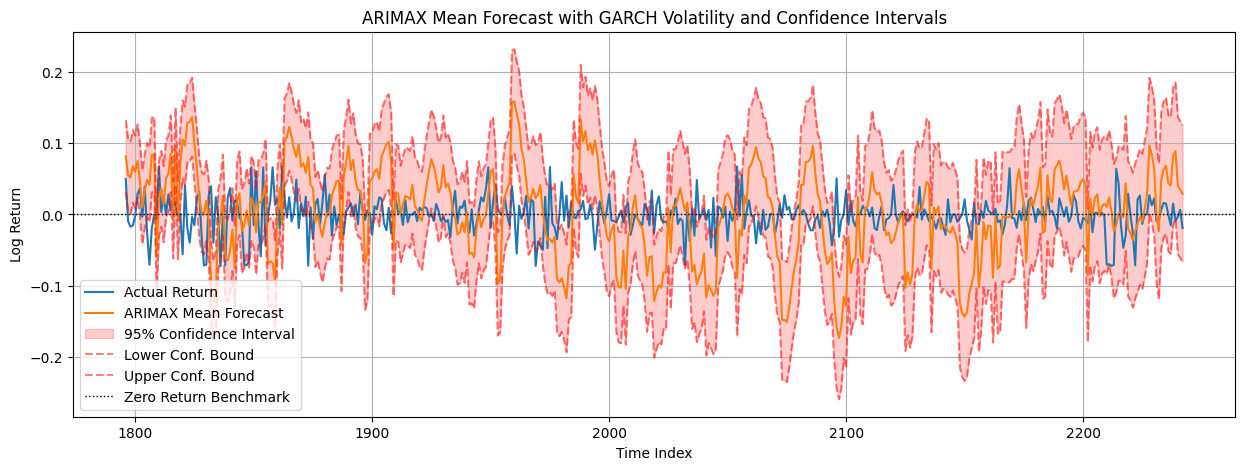

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(hybrid_forecast['Actual_Return'], label='Actual Return')
plt.plot(hybrid_forecast['ARIMAX_Mean'], label='ARIMAX Mean Forecast')

plt.fill_between(hybrid_forecast.index, hybrid_forecast['Lower_Conf_95'], hybrid_forecast['Upper_Conf_95'], color='red', alpha=0.2, label='95% Confidence Interval')

plt.plot(hybrid_forecast['Lower_Conf_95'], color='red', linestyle='--', alpha=0.5, label='Lower Conf. Bound')
plt.plot(hybrid_forecast['Upper_Conf_95'], color='red', linestyle='--', alpha=0.5, label='Upper Conf. Bound')
plt.axhline(0, color='black', linestyle=':', linewidth=1, label='Zero Return Benchmark') # Added benchmark
plt.title('ARIMAX Mean Forecast with GARCH Volatility and Confidence Intervals')
plt.xlabel('Time Index')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()

### 15-steps ahead plot:

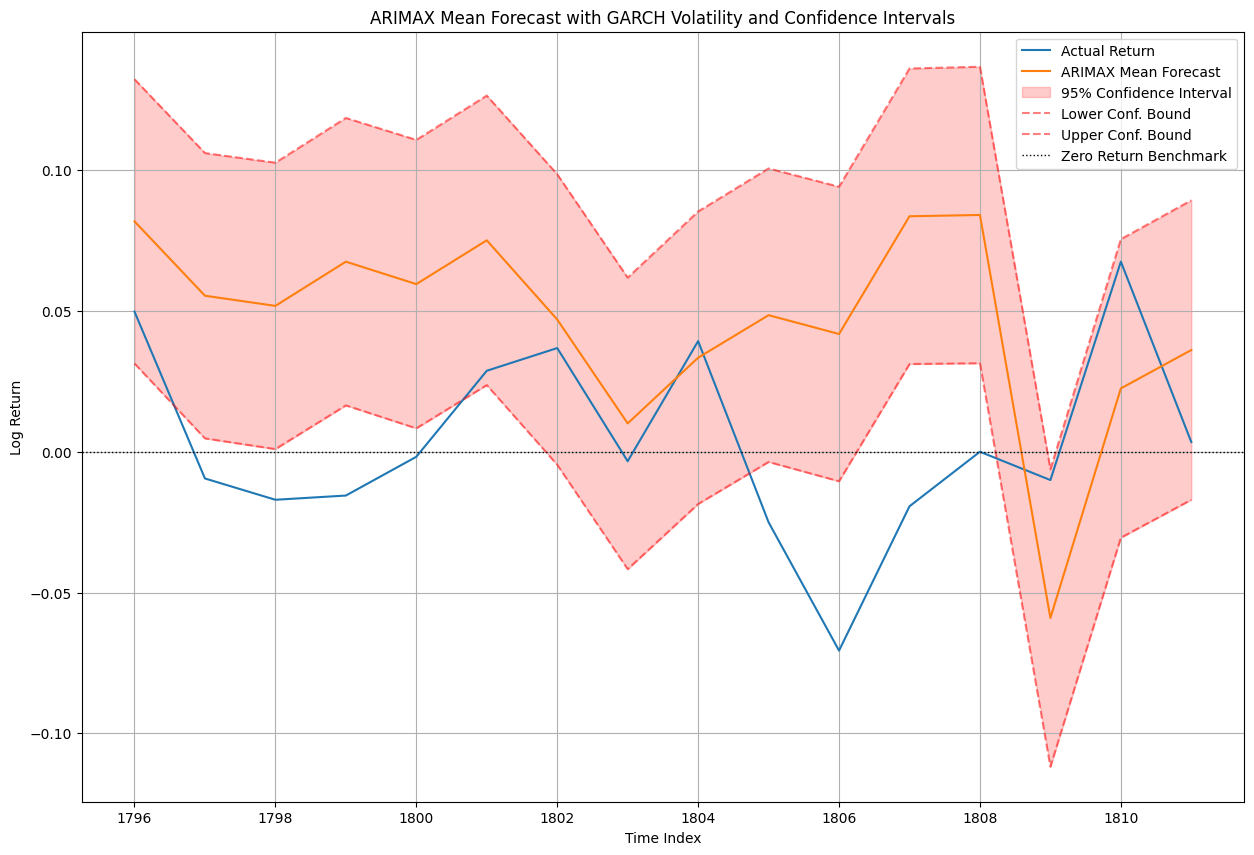

In [ ]:
plt.figure(figsize=(15, 10))

df = hybrid_forecast.iloc[:16]
plt.plot(df['Actual_Return'], label='Actual Return')
plt.plot(df['ARIMAX_Mean'], label='ARIMAX Mean Forecast')

plt.fill_between(df.index, df['Lower_Conf_95'], df['Upper_Conf_95'], color='red', alpha=0.2, label='95% Confidence Interval')

plt.plot(df['Lower_Conf_95'], color='red', linestyle='--', alpha=0.5, label='Lower Conf. Bound')
plt.plot(df['Upper_Conf_95'], color='red', linestyle='--', alpha=0.5, label='Upper Conf. Bound')
plt.axhline(0, color='black', linestyle=':', linewidth=1, label='Zero Return Benchmark')
plt.title('ARIMAX Mean Forecast with GARCH Volatility and Confidence Intervals')
plt.xlabel('Time Index')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()